# Anomaly Detection: Isolation Forest vs Variational Autoencoder
### Credit Card Fraud Detection | Kaggle Notebook

---

## What Is Anomaly Detection?

Imagine you receive 1,000 bank transactions a day. Out of those, maybe 2–3 are fraudulent. 
You can't label them all manually — and fraud patterns keep changing. **Anomaly detection** solves this by learning what "normal" looks like, then flagging anything that deviates significantly.

This notebook covers two popular approaches:

| Method | Type | Core Idea |
|---|---|---|
| **Isolation Forest** | Tree-based | Anomalies are easier to "isolate" in a decision tree |
| **Variational Autoencoder (VAE)** | Deep Learning | Anomalies have high reconstruction error |

---

## Notebook Structure

1. Setup & Imports
2. Load & Explore Data (EDA)
3. Preprocessing
4. Isolation Forest
5. Variational Autoencoder (VAE)
6. Side-by-Side Comparison
7. Key Takeaways

---
## 1. Setup & Imports

We use standard ML libraries. `TensorFlow/Keras` powers the VAE, while `scikit-learn` handles Isolation Forest and evaluation metrics.

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, f1_score
)
from sklearn.decomposition import PCA

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print('TensorFlow:', tf.__version__)
print('Setup complete.')

TensorFlow: 2.19.0
Setup complete.


---
## 2. Load & Explore the Data

### About the Dataset

The [Credit Card Fraud Detection dataset](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) contains **284,807 transactions** made by European cardholders in September 2013.

- **Features V1–V28**: PCA-transformed features (original features are anonymized for privacy)
- **Time**: Seconds elapsed since the first transaction
- **Amount**: Transaction amount in Euros
- **Class**: `0` = Normal, `1` = Fraud

**Key challenge**: Only **0.172%** of transactions are fraudulent — a severely imbalanced dataset.

In [38]:
df = pd.read_csv('/kaggle/input/datasets/blourdhuraju/credit-card-fraud-detection/creditcard.csv')

print(f'Shape: {df.shape}')
print(f'\nClass distribution:')
print(df['Class'].value_counts())
print(f'\nFraud rate: {df["Class"].mean()*100:.4f}%')
df.head()

Shape: (284807, 31)

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud rate: 0.1727%


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


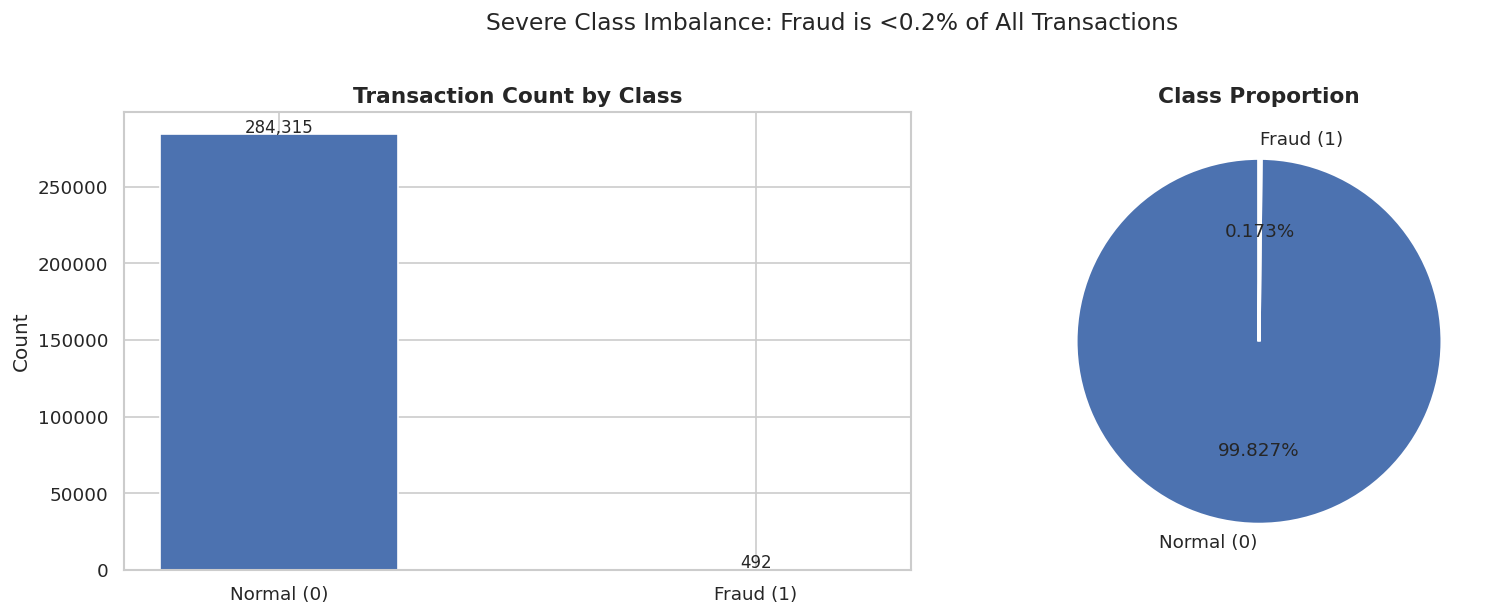

In [39]:
# ── EDA: Class Imbalance ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df['Class'].value_counts()
labels = ['Normal (0)', 'Fraud (1)']
colors = ['#4C72B0', '#DD8452']

# Bar chart
axes[0].bar(labels, counts.values, color=colors, width=0.5, edgecolor='white')
axes[0].set_title('Transaction Count by Class', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontsize=10)

# Pie chart
axes[1].pie(counts.values, labels=labels, autopct='%1.3f%%',
            colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Severe Class Imbalance: Fraud is <0.2% of All Transactions',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

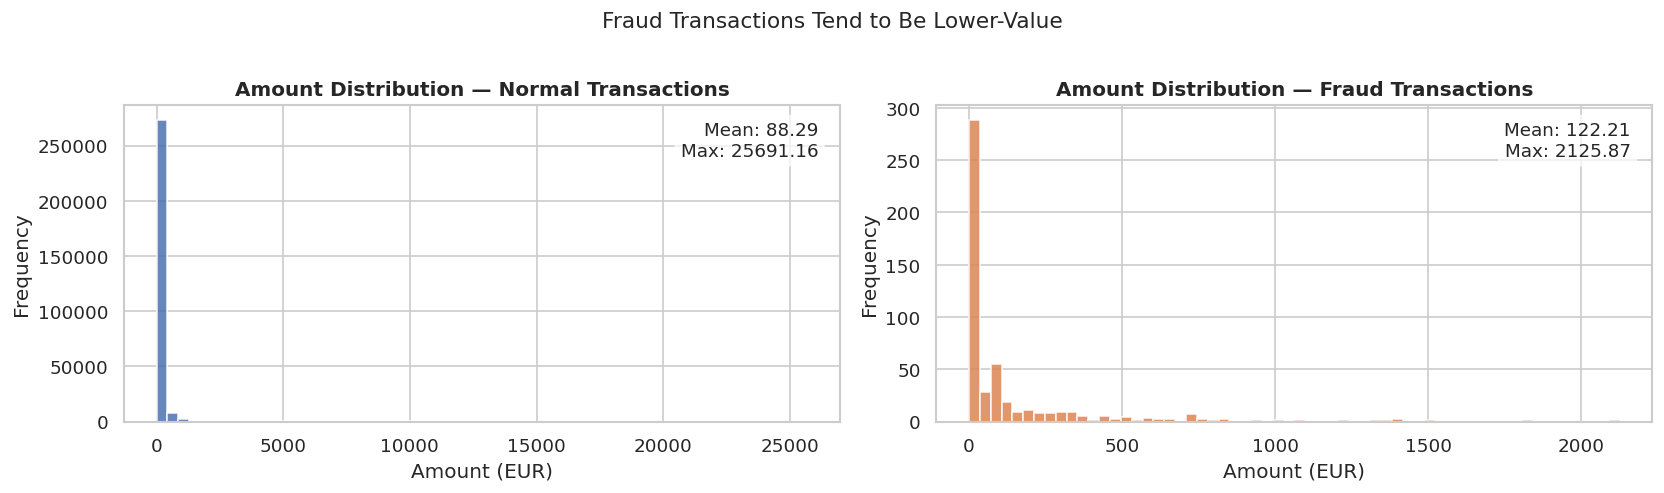

In [40]:
# ── EDA: Transaction Amount Distribution ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, label, color in zip(axes, [0, 1], colors):
    subset = df[df['Class'] == label]['Amount']
    ax.hist(subset, bins=60, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'Amount Distribution — {"Normal" if label==0 else "Fraud"} Transactions',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Amount (EUR)')
    ax.set_ylabel('Frequency')
    ax.text(0.97, 0.95, f'Mean: {subset.mean():.2f}\nMax: {subset.max():.2f}',
            transform=ax.transAxes, va='top', ha='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.suptitle('Fraud Transactions Tend to Be Lower-Value', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

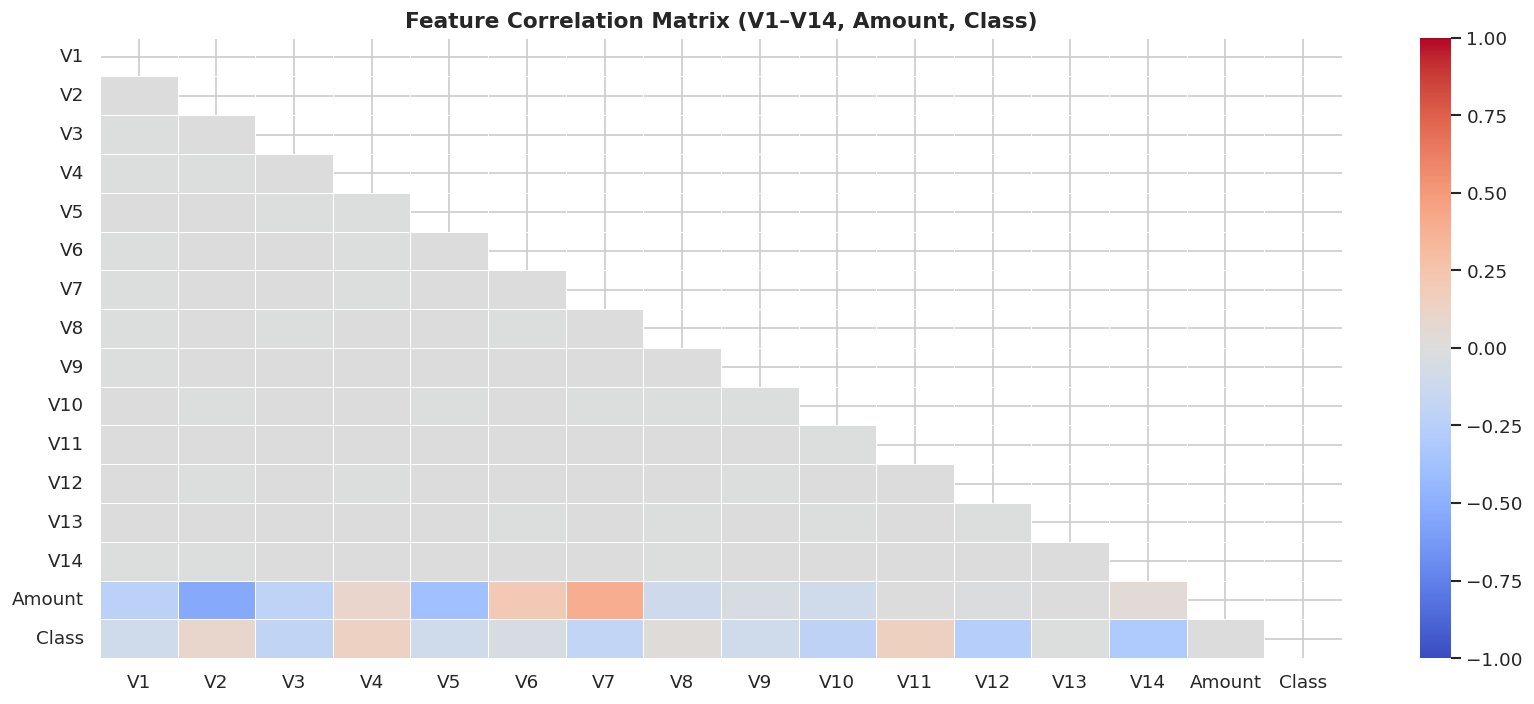

In [41]:
# ── EDA: Feature Correlation Heatmap ─────────────────────────────────────────
# Select a subset of features for readability
feature_cols = [f'V{i}' for i in range(1, 15)] + ['Amount']

plt.figure(figsize=(14, 6))
corr = df[feature_cols + ['Class']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm',
            center=0, linewidths=0.4, vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix (V1–V14, Amount, Class)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

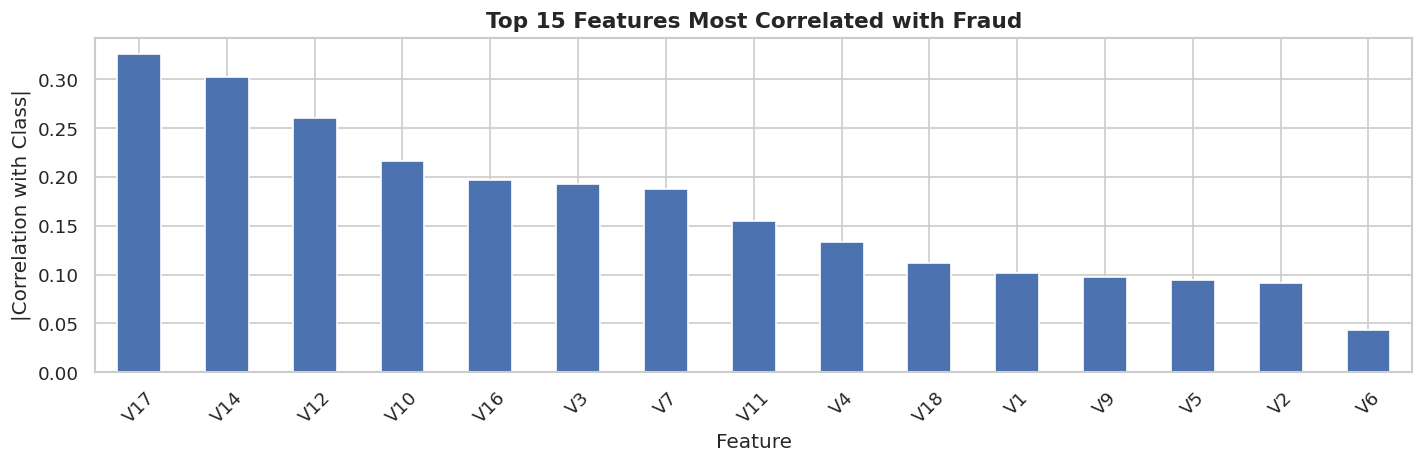

Top 5 features correlated with fraud:
V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
Name: Class, dtype: float64


In [42]:
# ── EDA: Top features correlated with fraud ───────────────────────────────────
all_features = [f'V{i}' for i in range(1, 29)] + ['Amount', 'Time']
fraud_corr = df[all_features + ['Class']].corr()['Class'].drop('Class').abs().sort_values(ascending=False)

plt.figure(figsize=(12, 4))
fraud_corr.head(15).plot(kind='bar', color='#4C72B0', edgecolor='white')
plt.title('Top 15 Features Most Correlated with Fraud', fontsize=13, fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('|Correlation with Class|')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('Top 5 features correlated with fraud:')
print(fraud_corr.head())

---
## 3. Preprocessing

### What We Do and Why

1. **Scale `Amount` and `Time`**: The V1–V28 features are already PCA-scaled. `Amount` and `Time` are not — we standardize them so no single feature dominates by magnitude.
2. **Train/Test Split**: We split the data so we can evaluate generalization. Both models train **only on normal transactions** — this is the essence of unsupervised anomaly detection.
3. **Why train on normals only?** Both Isolation Forest and VAE learn the "normal" distribution. Anything that doesn't fit well gets a high anomaly score at test time — including fraud.

In [43]:
from sklearn.model_selection import train_test_split

# Scale Amount and Time
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled']   = scaler.fit_transform(df[['Time']])

# Feature matrix
feature_cols = [f'V{i}' for i in range(1, 29)] + ['Amount_scaled', 'Time_scaled']
X = df[feature_cols].values
y = df['Class'].values

# Split — stratified to preserve fraud ratio
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# Training set: ONLY normal transactions (unsupervised)
X_train = X_train_full[y_train_full == 0]

print(f'Total samples     : {len(X):,}')
print(f'Train (normals)   : {len(X_train):,}')
print(f'Test (all classes): {len(X_test):,}')
print(f'Test fraud count  : {y_test.sum():,} ({y_test.mean()*100:.3f}%)')

Total samples     : 284,807
Train (normals)   : 227,451
Test (all classes): 56,962
Test fraud count  : 98 (0.172%)


---
## 4. Isolation Forest

### How It Works (Intuition)

Think of a random decision tree. At each node, we pick a random feature and a random split point. 

- **Normal points** are dense — they take **many splits** to isolate because they cluster together.
- **Anomalies** are sparse — they take **fewer splits** to isolate because they're outliers far from the cluster.

The anomaly score is the average path length across many trees. Short path = anomaly.

```
Normal point:   root → ... → ... → ... → ... → leaf  (deep path)
Anomaly:        root → ... → leaf                     (short path)
```

**Key hyperparameters:**
- `contamination`: Expected fraction of anomalies (we set it to the true fraud rate)
- `n_estimators`: Number of trees (more = more stable)
- `max_samples`: Subsampling size per tree

In [44]:
# ── Train Isolation Forest ────────────────────────────────────────────────────
fraud_rate = y_train_full.mean()  # true contamination estimate

iso_forest = IsolationForest(
    n_estimators=200,
    max_samples='auto',
    contamination=fraud_rate,
    random_state=SEED,
    n_jobs=-1
)

iso_forest.fit(X_train)  # fit on NORMAL transactions only
print('Isolation Forest trained.')

# Predict on test set
# IsolationForest returns: -1 (anomaly) or +1 (normal)
# We convert to 1 (fraud) and 0 (normal) to match y_test
iso_raw_scores = iso_forest.decision_function(X_test)  # higher = more normal
iso_anomaly_scores = -iso_raw_scores                   # flip: higher = more anomalous
iso_preds = (iso_forest.predict(X_test) == -1).astype(int)

print(f'\nPredicted fraud  : {iso_preds.sum():,}')
print(f'Actual fraud     : {y_test.sum():,}')

Isolation Forest trained.

Predicted fraud  : 112
Actual fraud     : 98


In [45]:
# ── Isolation Forest Evaluation ───────────────────────────────────────────────
print('=== Isolation Forest Classification Report ===')
print(classification_report(y_test, iso_preds, target_names=['Normal', 'Fraud']))

iso_auc = roc_auc_score(y_test, iso_anomaly_scores)
iso_ap  = average_precision_score(y_test, iso_anomaly_scores)
iso_f1  = f1_score(y_test, iso_preds)

print(f'ROC-AUC  : {iso_auc:.4f}')
print(f'Avg Prec : {iso_ap:.4f}')
print(f'F1 Score : {iso_f1:.4f}')

=== Isolation Forest Classification Report ===
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.20      0.22      0.21        98

    accuracy                           1.00     56962
   macro avg       0.60      0.61      0.60     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC  : 0.9488
Avg Prec : 0.1004
F1 Score : 0.2095


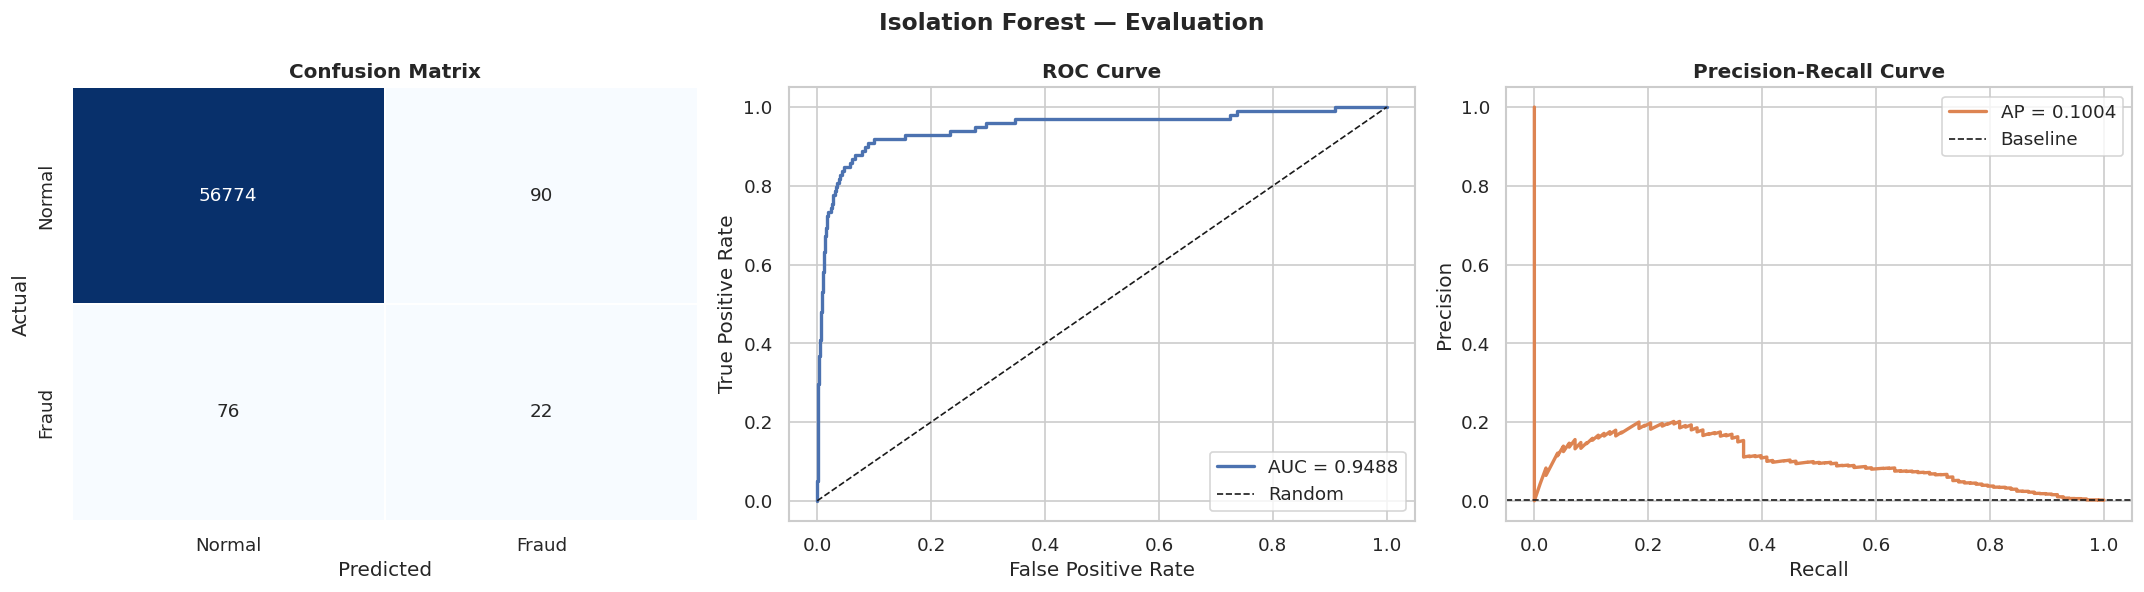

In [46]:
# ── Isolation Forest Visualizations ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, iso_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal', 'Fraud'],
            yticklabels=['Normal', 'Fraud'],
            linewidths=1, cbar=False)
axes[0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, iso_anomaly_scores)
axes[1].plot(fpr, tpr, color='#4C72B0', lw=2, label=f'AUC = {iso_auc:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=12, fontweight='bold')
axes[1].legend()

# 3. Precision-Recall Curve
prec, rec, _ = precision_recall_curve(y_test, iso_anomaly_scores)
axes[2].plot(rec, prec, color='#DD8452', lw=2, label=f'AP = {iso_ap:.4f}')
axes[2].axhline(y=y_test.mean(), color='k', linestyle='--', lw=1, label='Baseline')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
axes[2].legend()

plt.suptitle('Isolation Forest — Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

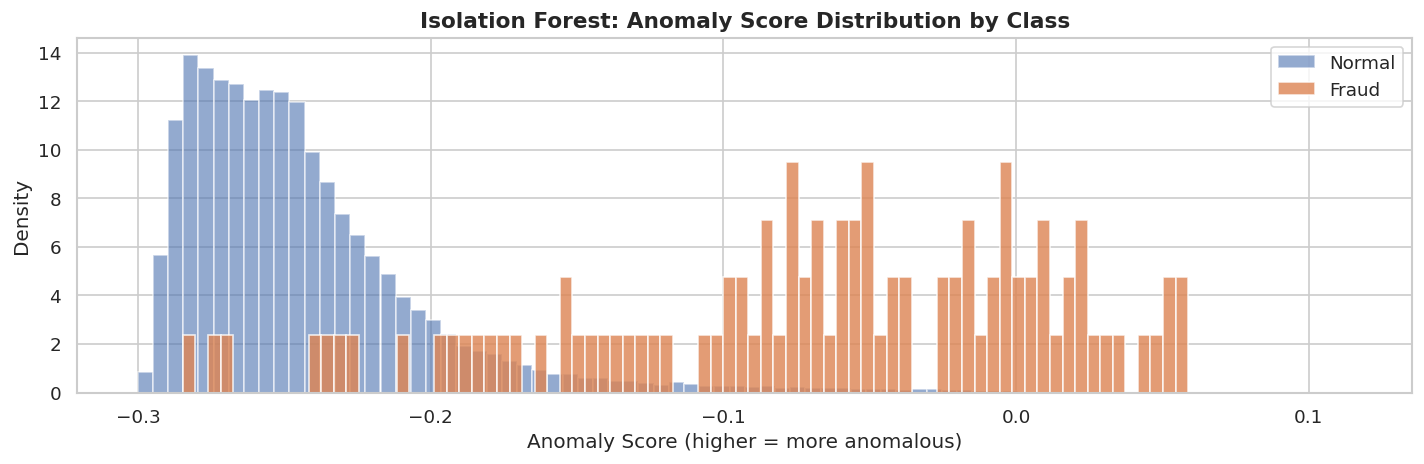

In [47]:
# ── Anomaly Score Distribution ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))

normal_scores = iso_anomaly_scores[y_test == 0]
fraud_scores  = iso_anomaly_scores[y_test == 1]

ax.hist(normal_scores, bins=80, color='#4C72B0', alpha=0.6, density=True, label='Normal')
ax.hist(fraud_scores,  bins=80, color='#DD8452', alpha=0.8, density=True, label='Fraud')
ax.set_xlabel('Anomaly Score (higher = more anomalous)')
ax.set_ylabel('Density')
ax.set_title('Isolation Forest: Anomaly Score Distribution by Class',
             fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

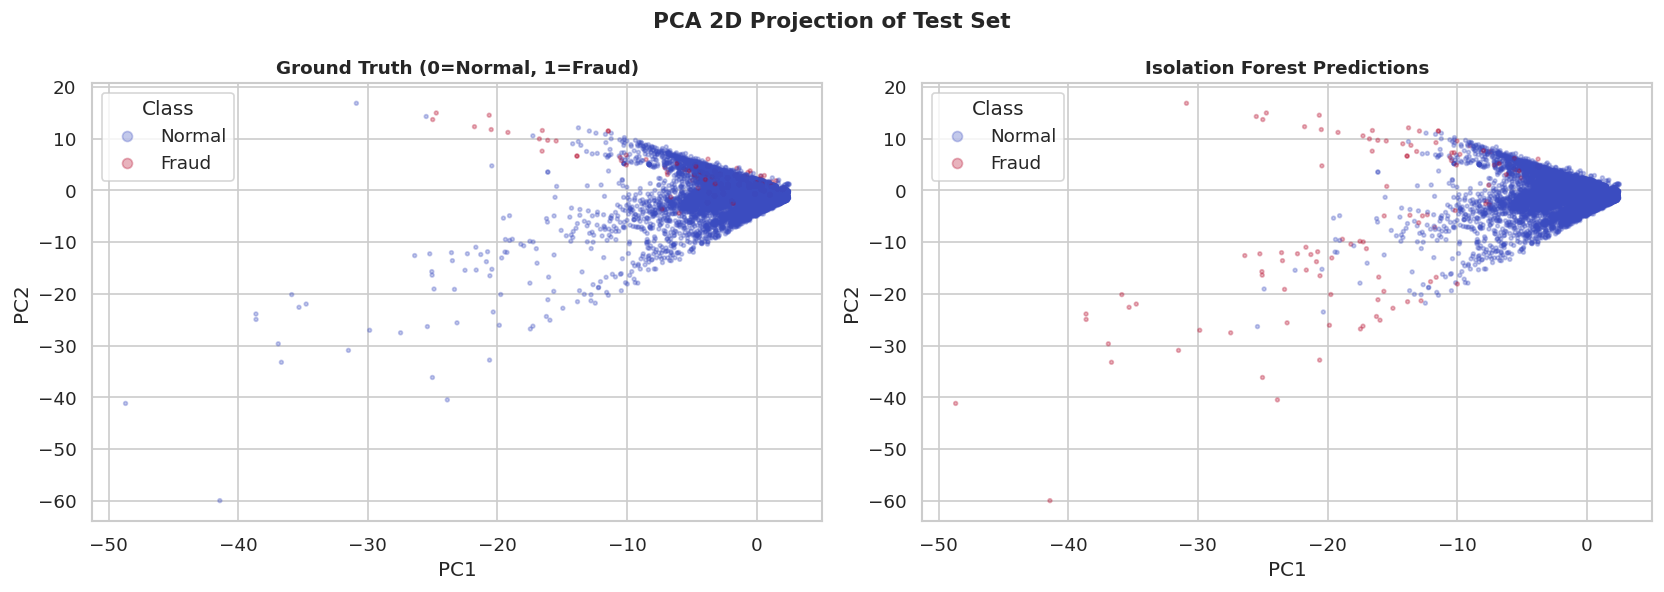

In [48]:
# ── PCA Visualization of Isolation Forest Decisions ──────────────────────────
# Reduce test set to 2D with PCA for visual inspection
pca = PCA(n_components=2, random_state=SEED)
X_test_2d = pca.fit_transform(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, labels, title in zip(
    axes,
    [y_test, iso_preds],
    ['Ground Truth (0=Normal, 1=Fraud)', 'Isolation Forest Predictions']
):
    scatter = ax.scatter(
        X_test_2d[:, 0], X_test_2d[:, 1],
        c=labels, cmap='coolwarm', alpha=0.3, s=5, rasterized=True
    )
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    legend = ax.legend(*scatter.legend_elements(), title='Class')
    legend.get_texts()[0].set_text('Normal')
    legend.get_texts()[1].set_text('Fraud')

plt.suptitle('PCA 2D Projection of Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Variational Autoencoder (VAE)

### How It Works (Intuition)

A **regular autoencoder** compresses data into a small "bottleneck" (latent space) and reconstructs it. A **VAE** goes one step further — instead of encoding a point, it encodes a **probability distribution** (mean + variance). This forces the latent space to be smooth and continuous.

**For anomaly detection:**
1. Train the VAE on **normal** transactions only
2. It learns to reconstruct normal patterns with low error
3. At inference, fraudulent transactions don't fit the learned distribution — so reconstruction error is **high**
4. We use this reconstruction error as an **anomaly score**

**Architecture used:**
```
Input (30) → Dense(64) → Dense(32) → [μ, σ] → Latent z (16)
                                                      ↓
Output (30) ← Dense(64) ← Dense(32) ←────────── Decoder
```

**VAE Loss = Reconstruction Loss + KL Divergence**
- Reconstruction loss: How well can we rebuild the input?
- KL divergence: How close is our latent distribution to a standard normal?

In [49]:
# ── VAE Architecture ──────────────────────────────────────────────────────────

INPUT_DIM  = X_train.shape[1]   # 30 features
LATENT_DIM = 16

# ── Sampling layer ──
class Sampling(layers.Layer):
    """Reparameterization trick: z = mu + eps * sigma"""
    def call(self, inputs):
        mu, log_var = inputs
        eps = tf.random.normal(tf.shape(mu))
        return mu + tf.exp(0.5 * log_var) * eps

# ── Encoder ──
encoder_inputs = keras.Input(shape=(INPUT_DIM,))
x = layers.Dense(64, activation='relu')(encoder_inputs)
x = layers.BatchNormalization()(x)
x = layers.Dense(32, activation='relu')(x)
x = layers.BatchNormalization()(x)
z_mean    = layers.Dense(LATENT_DIM, name='z_mean')(x)
z_log_var = layers.Dense(LATENT_DIM, name='z_log_var')(x)
z         = Sampling()([z_mean, z_log_var])

encoder = Model(encoder_inputs, [z_mean, z_log_var, z], name='encoder')

# ── Decoder ──
latent_inputs = keras.Input(shape=(LATENT_DIM,))
x = layers.Dense(32, activation='relu')(latent_inputs)
x = layers.BatchNormalization()(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.BatchNormalization()(x)
decoder_outputs = layers.Dense(INPUT_DIM)(x)  # linear output for reconstruction

decoder = Model(latent_inputs, decoder_outputs, name='decoder')

print('Encoder:')
encoder.summary()
print('\nDecoder:')
decoder.summary()

Encoder:


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 30)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 64)        │      1,984 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_10[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 32)        │      2,080 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32)        │        128 │ dense_11[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 16)        │        528 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 16)        │        528 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling_2          │ (None, 16)        │          0 │ z_mean[0][0],     │
│ (Sampling)          │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,504 (21.50 KB)

 Trainable params: 5,312 (20.75 KB)

...

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 30)             │         1,950 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,990 (19.49 KB)

 Trainable params: 4,798 (18.74 KB)

 Non-trainable params: 192 (768.00 B)

In [50]:
class VAE(Model):
    def __init__(self, encoder, decoder, beta=1.0, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.beta    = beta

        self.total_loss_tracker   = keras.metrics.Mean(name='total_loss')
        self.recon_loss_tracker   = keras.metrics.Mean(name='recon_loss')
        self.kl_loss_tracker      = keras.metrics.Mean(name='kl_loss')

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.recon_loss_tracker, self.kl_loss_tracker]

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]  # unpack (x, y) — y unused in autoencoders
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)

            recon_loss = tf.reduce_mean(
                tf.reduce_sum(tf.square(data - reconstruction), axis=1)
            )
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
            )
            total_loss = recon_loss + self.beta * kl_loss

        grads = tape.gradient(total_loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))

        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        return self.decoder(z)


vae = VAE(encoder, decoder, beta=1.0)
vae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss='mse')
print('VAE compiled.')

VAE compiled.


In [51]:
# Manual validation split — avoids Keras 3 custom train_step issues
val_size = int(len(X_train) * 0.1)
X_val_vae   = X_train[:val_size]
X_train_vae = X_train[val_size:]

EPOCHS     = 50
BATCH_SIZE = 256

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = vae.fit(
    X_train_vae,
    validation_data=(X_val_vae, X_val_vae),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)

print('\nVAE training complete.')

Epoch 1/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - kl_loss: 1.6440 - recon_loss: 27.8368 - total_loss: 29.4808 - val_kl_loss: 0.0000e+00 - val_recon_loss: 0.0000e+00 - val_total_loss: 0.0000e+00
Epoch 2/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - kl_loss: 4.2479 - recon_loss: 16.2211 - total_loss: 20.4690 - val_kl_loss: 0.0000e+00 - val_recon_loss: 0.0000e+00 - val_total_loss: 0.0000e+00
Epoch 3/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - kl_loss: 4.8537 - recon_loss: 13.2873 - total_loss: 18.1410 - val_kl_loss: 0.0000e+00 - val_recon_loss: 0.0000e+00 - val_total_loss: 0.0000e+00
Epoch 4/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - kl_loss: 5.2395 - recon_loss: 11.7127 - total_loss: 16.9522 - val_kl_loss: 0.0000e+00 - val_recon_loss: 0.0000e+00 - val_total_loss: 0.0000e+00
Epoch 5/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - kl_loss: 5.4447 - recon_loss: 10.8865 - total_loss: 16.3312 - val_kl_loss: 0.0000e+00 - val_recon_loss: 0.0000e+00 - val_total_loss: 0.0000e+00
Epoch 6/5

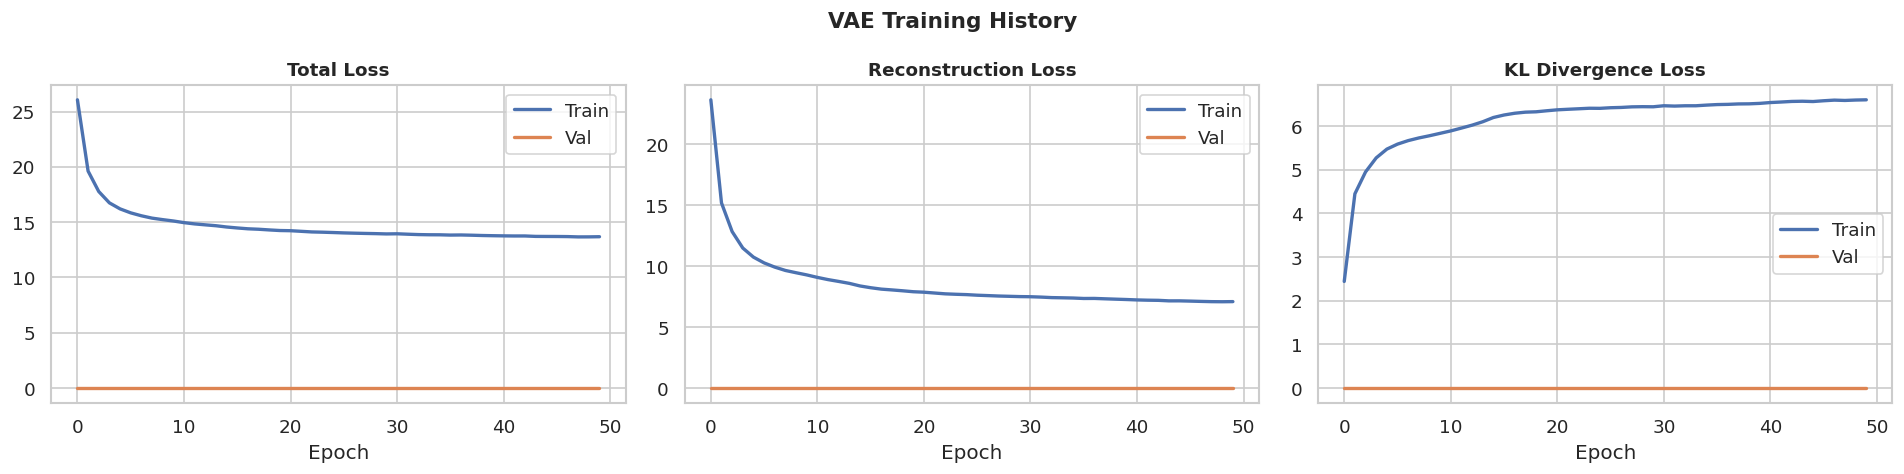

In [52]:
# ── Training Loss Curves ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, key, title in zip(
    axes,
    ['total_loss', 'recon_loss', 'kl_loss'],
    ['Total Loss', 'Reconstruction Loss', 'KL Divergence Loss']
):
    ax.plot(history.history[key],     label='Train', color='#4C72B0', lw=2)
    val_key = f'val_{key}'
    if val_key in history.history:
        ax.plot(history.history[val_key], label='Val',   color='#DD8452', lw=2)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend()

plt.suptitle('VAE Training History', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [53]:
# ── VAE Anomaly Scoring ───────────────────────────────────────────────────────
# Reconstruction error per sample = per-feature squared error summed

X_test_reconstructed = vae.predict(X_test, batch_size=512, verbose=0)
vae_recon_errors = np.mean(np.square(X_test - X_test_reconstructed), axis=1)

# Threshold: 95th percentile of reconstruction errors on normal training samples
X_train_recon = vae.predict(X_train, batch_size=512, verbose=0)
train_recon_errors = np.mean(np.square(X_train - X_train_recon), axis=1)
vae_threshold = np.percentile(train_recon_errors, 95)

vae_preds = (vae_recon_errors > vae_threshold).astype(int)

print(f'VAE threshold (95th pct): {vae_threshold:.4f}')
print(f'Predicted fraud  : {vae_preds.sum():,}')
print(f'Actual fraud     : {y_test.sum():,}')

VAE threshold (95th pct): 0.5545
Predicted fraud  : 2,978
Actual fraud     : 98


In [54]:
# ── VAE Evaluation ────────────────────────────────────────────────────────────
print('=== VAE Classification Report ===')
print(classification_report(y_test, vae_preds, target_names=['Normal', 'Fraud']))

vae_auc = roc_auc_score(y_test, vae_recon_errors)
vae_ap  = average_precision_score(y_test, vae_recon_errors)
vae_f1  = f1_score(y_test, vae_preds)

print(f'ROC-AUC  : {vae_auc:.4f}')
print(f'Avg Prec : {vae_ap:.4f}')
print(f'F1 Score : {vae_f1:.4f}')

=== VAE Classification Report ===
              precision    recall  f1-score   support

      Normal       1.00      0.95      0.97     56864
       Fraud       0.03      0.81      0.05        98

    accuracy                           0.95     56962
   macro avg       0.51      0.88      0.51     56962
weighted avg       1.00      0.95      0.97     56962

ROC-AUC  : 0.9285
Avg Prec : 0.3084
F1 Score : 0.0514


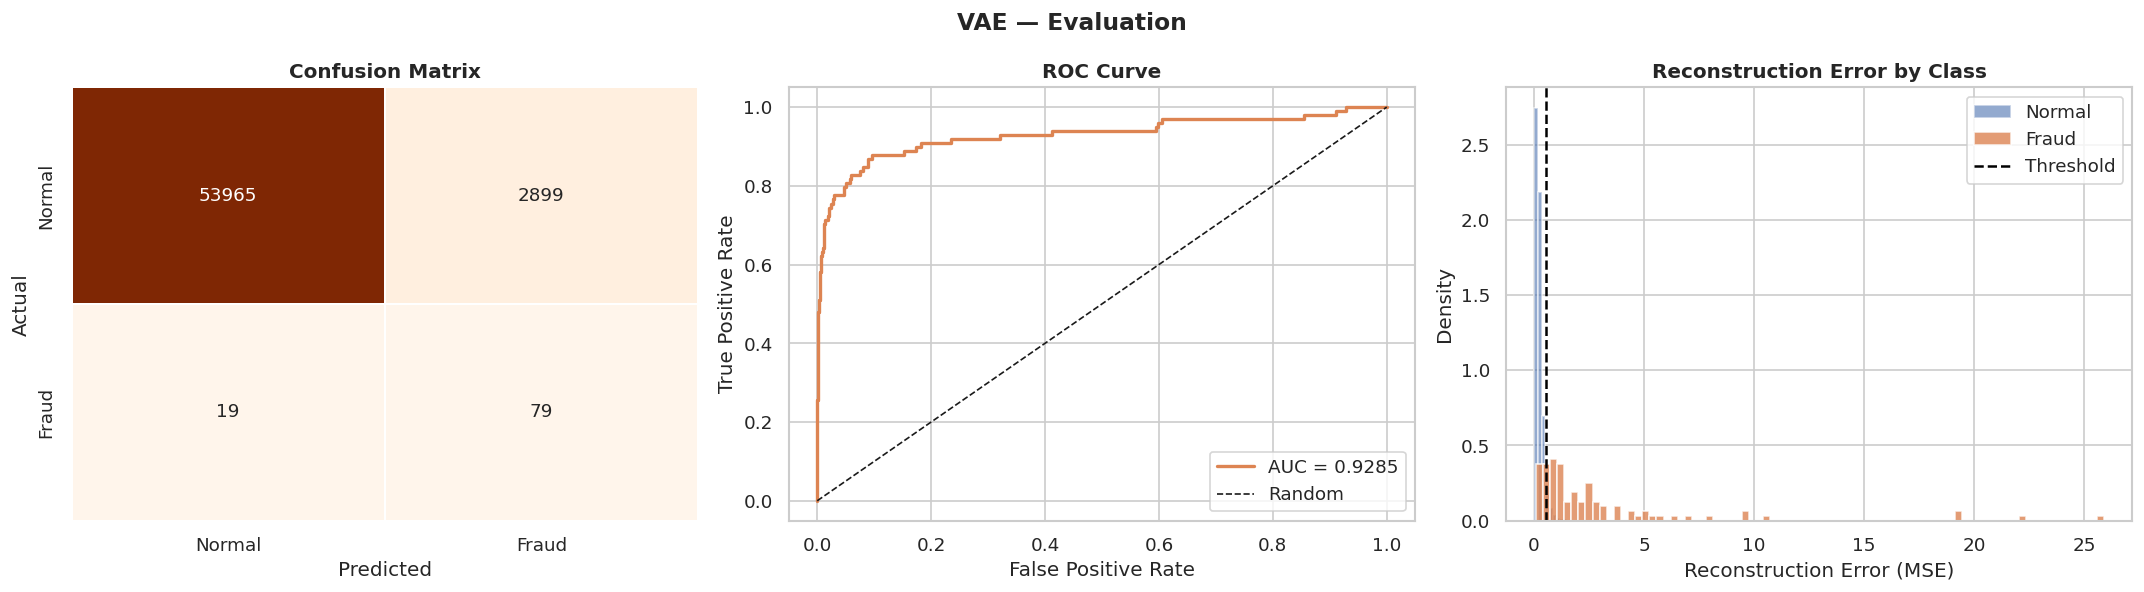

In [55]:
# ── VAE Evaluation Plots ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion Matrix
cm_vae = confusion_matrix(y_test, vae_preds)
sns.heatmap(cm_vae, annot=True, fmt='d', cmap='Oranges', ax=axes[0],
            xticklabels=['Normal', 'Fraud'],
            yticklabels=['Normal', 'Fraud'],
            linewidths=1, cbar=False)
axes[0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# 2. ROC Curve
fpr_v, tpr_v, _ = roc_curve(y_test, vae_recon_errors)
axes[1].plot(fpr_v, tpr_v, color='#DD8452', lw=2, label=f'AUC = {vae_auc:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=12, fontweight='bold')
axes[1].legend()

# 3. Reconstruction error distribution
axes[2].hist(vae_recon_errors[y_test == 0], bins=80, color='#4C72B0', alpha=0.6,
             density=True, label='Normal')
axes[2].hist(vae_recon_errors[y_test == 1], bins=80, color='#DD8452', alpha=0.8,
             density=True, label='Fraud')
axes[2].axvline(vae_threshold, color='black', lw=1.5, linestyle='--', label='Threshold')
axes[2].set_xlabel('Reconstruction Error (MSE)')
axes[2].set_ylabel('Density')
axes[2].set_title('Reconstruction Error by Class', fontsize=12, fontweight='bold')
axes[2].legend()

plt.suptitle('VAE — Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

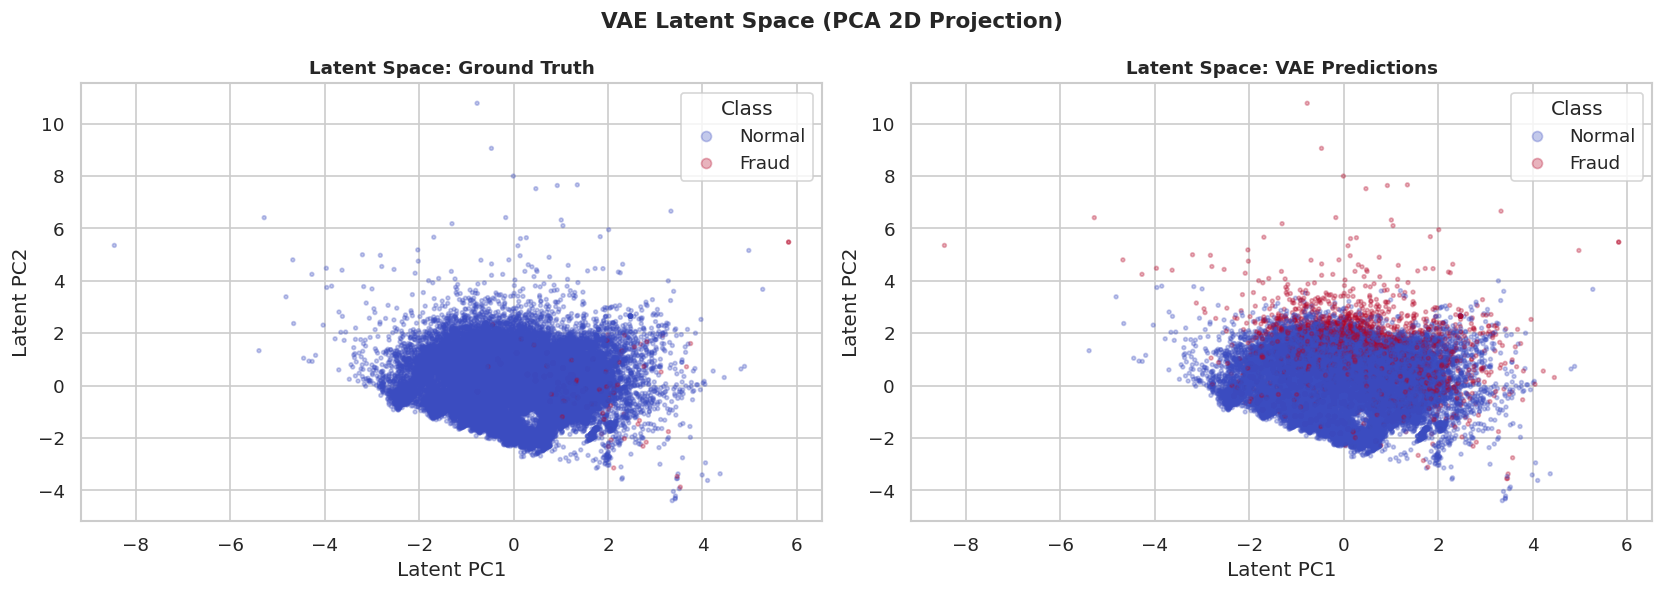

In [56]:
# ── VAE Latent Space Visualization ───────────────────────────────────────────
# Encode test set into latent space and visualize with PCA

z_mean_test, _, _ = encoder.predict(X_test, batch_size=512, verbose=0)

pca_latent = PCA(n_components=2, random_state=SEED)
z_2d = pca_latent.fit_transform(z_mean_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, labels, title, cmap in zip(
    axes,
    [y_test, vae_preds],
    ['Latent Space: Ground Truth', 'Latent Space: VAE Predictions'],
    ['coolwarm', 'coolwarm']
):
    sc = ax.scatter(z_2d[:, 0], z_2d[:, 1], c=labels, cmap=cmap,
                    alpha=0.3, s=5, rasterized=True)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Latent PC1')
    ax.set_ylabel('Latent PC2')
    legend = ax.legend(*sc.legend_elements(), title='Class')
    legend.get_texts()[0].set_text('Normal')
    legend.get_texts()[1].set_text('Fraud')

plt.suptitle('VAE Latent Space (PCA 2D Projection)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Side-by-Side Comparison

Now that both models are trained and evaluated, let's compare them head-to-head.

### Metrics to Focus On for Imbalanced Data

- **Accuracy** is misleading here — a model that predicts "Normal" 100% of the time gets 99.8% accuracy!
- **Precision**: Of all the transactions we flagged as fraud, how many were actually fraud?
- **Recall (Sensitivity)**: Of all actual frauds, how many did we catch?
- **F1**: Harmonic mean of Precision and Recall
- **Average Precision (AP)**: Area under the Precision-Recall curve — best single metric for imbalanced classification
- **ROC-AUC**: Area under the ROC curve

In [57]:
# ── Metrics Summary Table ─────────────────────────────────────────────────────
from sklearn.metrics import precision_score, recall_score

results = pd.DataFrame({
    'Model': ['Isolation Forest', 'VAE'],
    'ROC-AUC':   [iso_auc,  vae_auc],
    'Avg Prec':  [iso_ap,   vae_ap],
    'F1 Score':  [iso_f1,   vae_f1],
    'Precision': [
        precision_score(y_test, iso_preds, zero_division=0),
        precision_score(y_test, vae_preds, zero_division=0)
    ],
    'Recall': [
        recall_score(y_test, iso_preds),
        recall_score(y_test, vae_preds)
    ],
})

print(results.to_string(index=False))
results

           Model  ROC-AUC  Avg Prec  F1 Score  Precision   Recall
Isolation Forest 0.948777  0.100406  0.209524   0.196429 0.224490
             VAE 0.928528  0.308450  0.051365   0.026528 0.806122


,Model,ROC-AUC,Avg Prec,F1 Score,Precision,Recall
0,Isolation Forest,0.948777,0.100406,0.209524,0.196429,0.224490
1,VAE,0.928528,0.308450,0.051365,0.026528,0.806122


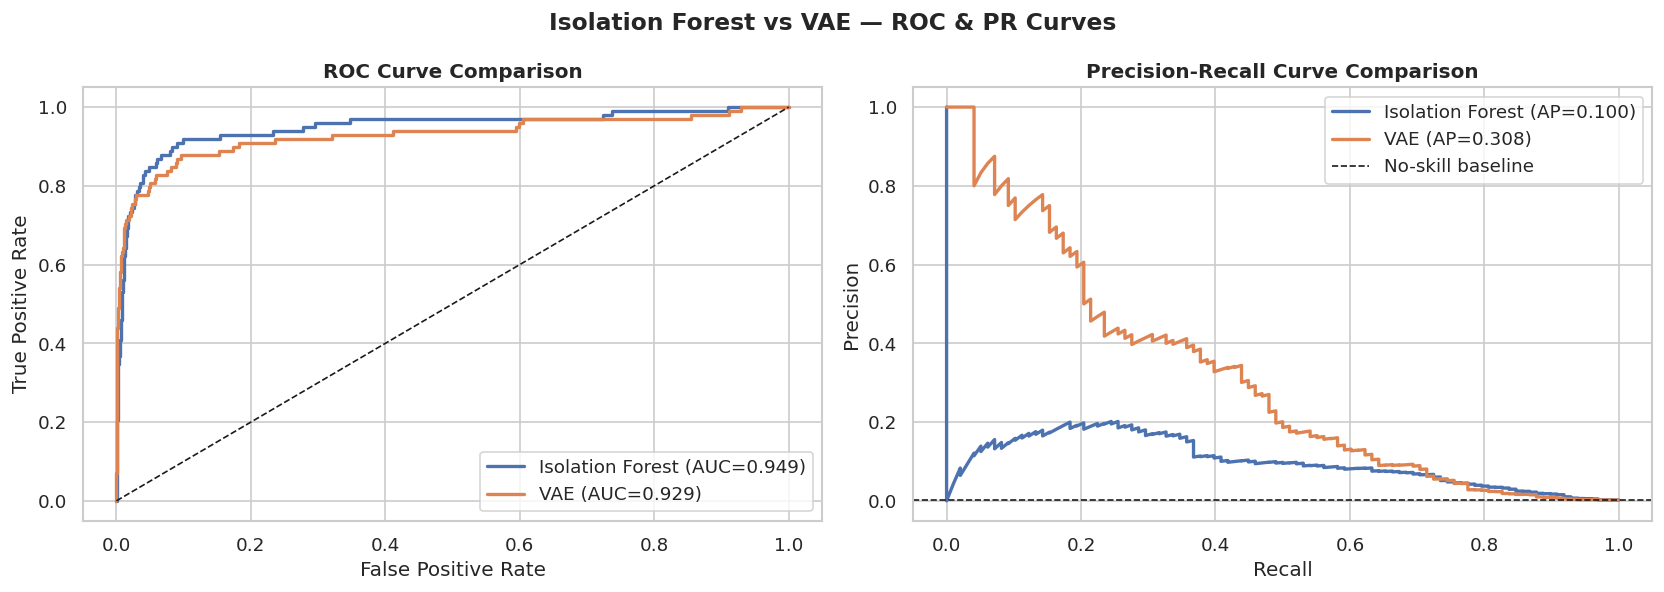

In [58]:
# ── Comparison: ROC & PR Curves on Same Axes ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC
for score, label, color in [
    (iso_anomaly_scores, f'Isolation Forest (AUC={iso_auc:.3f})', '#4C72B0'),
    (vae_recon_errors,   f'VAE (AUC={vae_auc:.3f})',              '#DD8452')
]:
    fpr_, tpr_, _ = roc_curve(y_test, score)
    axes[0].plot(fpr_, tpr_, label=label, lw=2, color=color)
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve Comparison', fontsize=12, fontweight='bold')
axes[0].legend()

# Precision-Recall
for score, label, color in [
    (iso_anomaly_scores, f'Isolation Forest (AP={iso_ap:.3f})', '#4C72B0'),
    (vae_recon_errors,   f'VAE (AP={vae_ap:.3f})',              '#DD8452')
]:
    prec_, rec_, _ = precision_recall_curve(y_test, score)
    axes[1].plot(rec_, prec_, label=label, lw=2, color=color)
axes[1].axhline(y=y_test.mean(), color='k', linestyle='--', lw=1, label='No-skill baseline')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve Comparison', fontsize=12, fontweight='bold')
axes[1].legend()

plt.suptitle('Isolation Forest vs VAE — ROC & PR Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

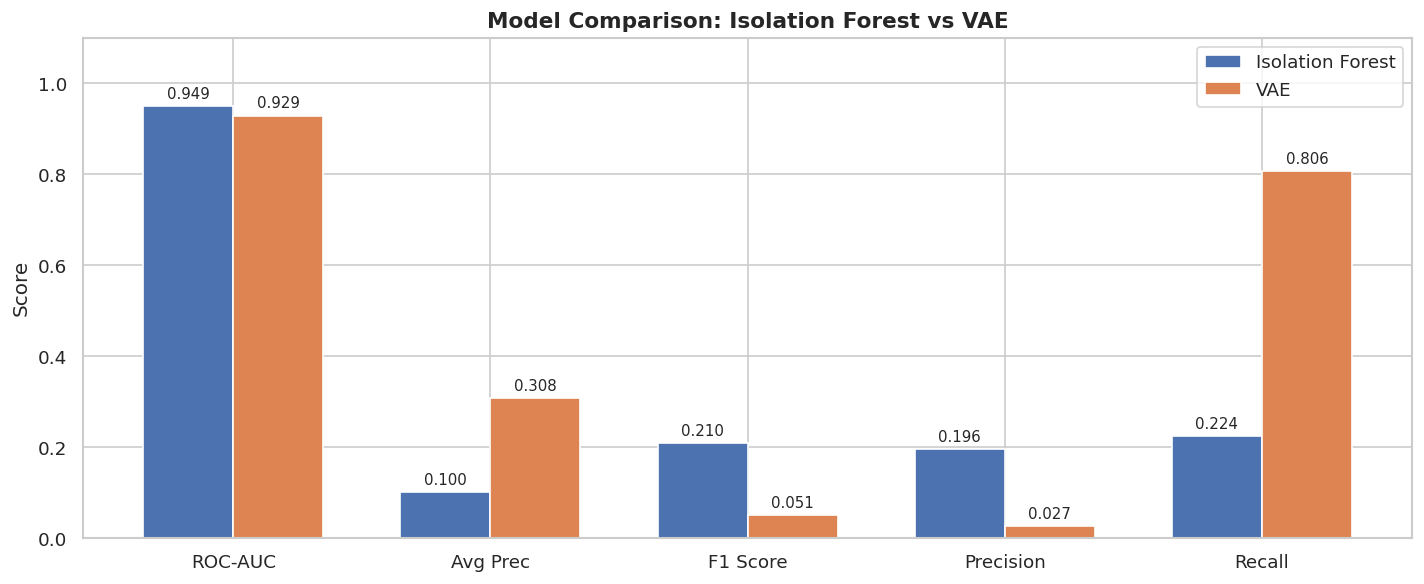

In [59]:
# ── Comparison: Bar Chart of Key Metrics ──────────────────────────────────────
metric_cols = ['ROC-AUC', 'Avg Prec', 'F1 Score', 'Precision', 'Recall']
x = np.arange(len(metric_cols))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, results[results['Model'] == 'Isolation Forest'][metric_cols].values[0],
               width, label='Isolation Forest', color='#4C72B0', edgecolor='white')
bars2 = ax.bar(x + width/2, results[results['Model'] == 'VAE'][metric_cols].values[0],
               width, label='VAE', color='#DD8452', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(metric_cols)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Model Comparison: Isolation Forest vs VAE', fontsize=13, fontweight='bold')
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

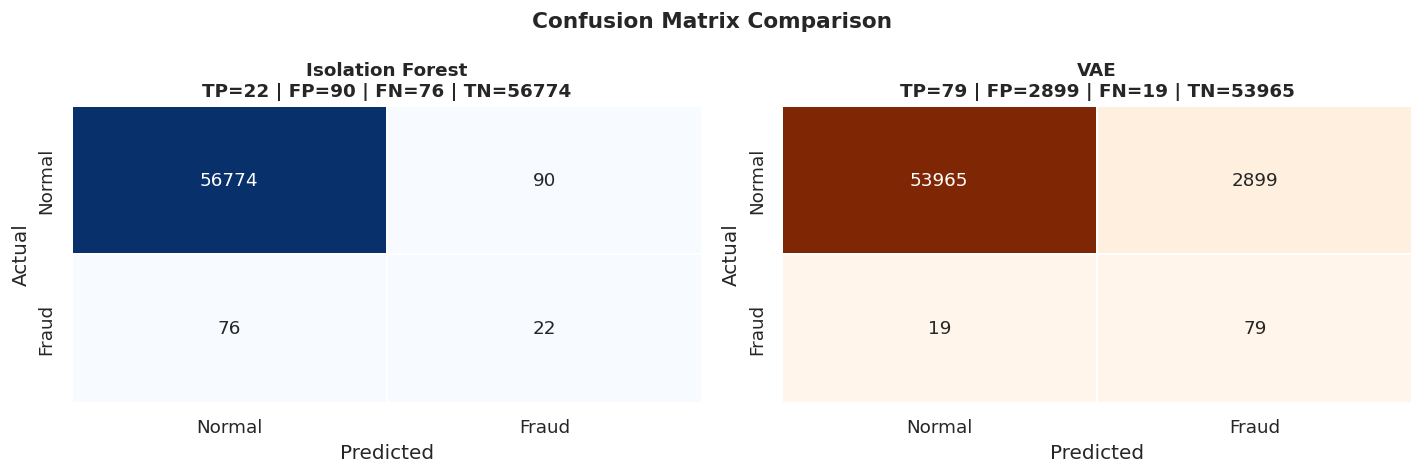

In [60]:
# ── Confusion Matrices Side by Side ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, preds, title, cmap in zip(
    axes,
    [iso_preds, vae_preds],
    ['Isolation Forest', 'VAE'],
    ['Blues', 'Oranges']
):
    cm_ = confusion_matrix(y_test, preds)
    tn, fp, fn, tp = cm_.ravel()
    sns.heatmap(cm_, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['Normal', 'Fraud'],
                yticklabels=['Normal', 'Fraud'],
                linewidths=1, cbar=False)
    ax.set_title(f'{title}\nTP={tp} | FP={fp} | FN={fn} | TN={tn}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrix Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

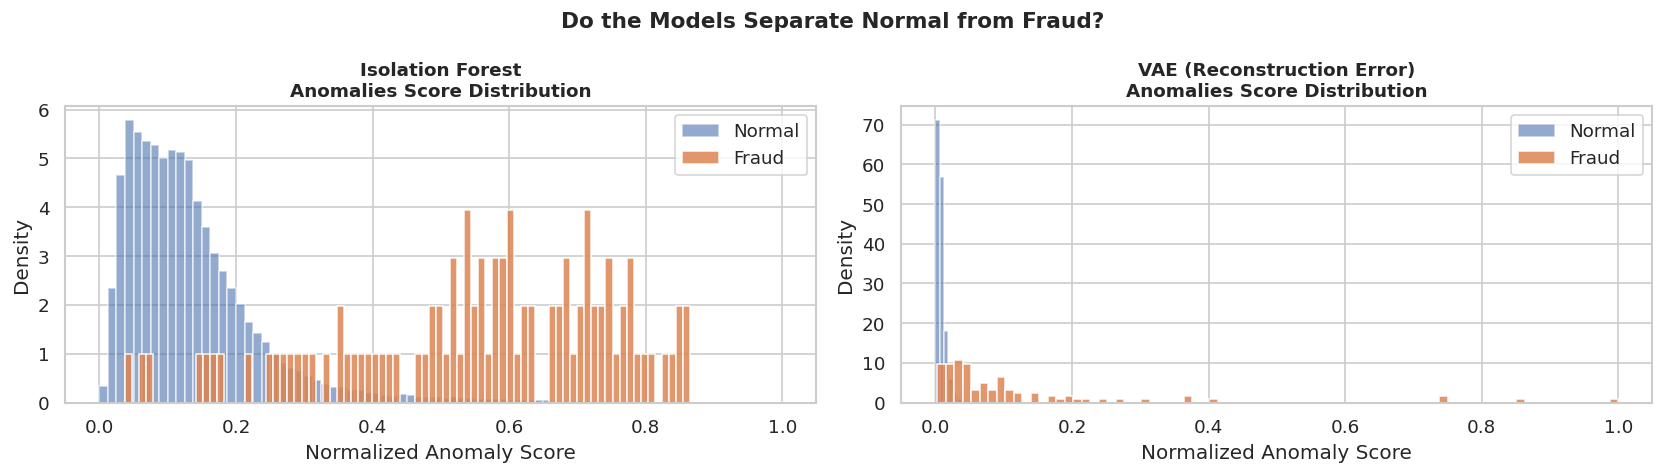

In [61]:
# ── Anomaly Score Distributions Overlaid ─────────────────────────────────────
# Normalize scores to [0, 1] for fair visual comparison
from sklearn.preprocessing import MinMaxScaler

iso_norm = MinMaxScaler().fit_transform(iso_anomaly_scores.reshape(-1, 1)).ravel()
vae_norm = MinMaxScaler().fit_transform(vae_recon_errors.reshape(-1, 1)).ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)

for ax, scores, title in zip(
    axes,
    [iso_norm, vae_norm],
    ['Isolation Forest', 'VAE (Reconstruction Error)']
):
    ax.hist(scores[y_test == 0], bins=80, color='#4C72B0', alpha=0.6, density=True, label='Normal')
    ax.hist(scores[y_test == 1], bins=80, color='#DD8452', alpha=0.85, density=True, label='Fraud')
    ax.set_title(f'{title}\nAnomalies Score Distribution', fontsize=11, fontweight='bold')
    ax.set_xlabel('Normalized Anomaly Score')
    ax.set_ylabel('Density')
    ax.legend()

plt.suptitle('Do the Models Separate Normal from Fraud?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. Key Takeaways

### When to Use Each Model

| Aspect | Isolation Forest | VAE |
|---|---|---|
| **Training speed** | Very fast | Slower (needs GPU for scale) |
| **Interpretability** | Moderate (path length) | Low (latent space is abstract) |
| **Works on tabular data** | Excellent | Good |
| **Captures complex patterns** | Limited | High |
| **Needs hyperparameter tuning** | Minimal | More careful tuning needed |
| **Production readiness** | Easy to deploy | Requires model serving |

### Threshold Selection

Both models produce a **score**, not a hard prediction. The threshold you pick dramatically affects the **Precision-Recall tradeoff**:
- Lower threshold → catch more fraud (high recall) but more false alarms (lower precision)
- Higher threshold → fewer false alarms but some fraud slips through

**Business decision**: In fraud detection, missing a fraud is usually more costly than a false alarm. So you'd typically optimize for **high recall**.

### What Could Be Done Next?

1. **Threshold tuning**: Use the PR curve to pick the optimal threshold for your business cost function
2. **Ensemble**: Combine IF + VAE scores (e.g., average normalized scores) for potentially better coverage
3. **UMAP instead of PCA**: Better visualization of the latent space
4. **Feature engineering**: Add transaction velocity, merchant category, etc. if available
5. **Online learning**: Retrain periodically as fraud patterns evolve

In [62]:
# ── Bonus: Ensemble Score (IF + VAE Combined) ─────────────────────────────────
# Simple ensemble: average of normalized anomaly scores from both models

ensemble_scores = (iso_norm + vae_norm) / 2

# Use the mean of the two thresholds as the ensemble threshold
iso_thresh_norm = MinMaxScaler().fit_transform(
    np.array([iso_forest.decision_function(X_train).mean()]).reshape(-1, 1)
).ravel()[0]
ensemble_threshold = 0.5  # 50th percentile as a starting point

ensemble_preds = (ensemble_scores > ensemble_threshold).astype(int)

ensemble_auc = roc_auc_score(y_test, ensemble_scores)
ensemble_ap  = average_precision_score(y_test, ensemble_scores)
ensemble_f1  = f1_score(y_test, ensemble_preds)

print('=== Ensemble (IF + VAE) ===')
print(classification_report(y_test, ensemble_preds, target_names=['Normal', 'Fraud']))
print(f'ROC-AUC  : {ensemble_auc:.4f}')
print(f'Avg Prec : {ensemble_ap:.4f}')
print(f'F1 Score : {ensemble_f1:.4f}')

=== Ensemble (IF + VAE) ===
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.37      0.07      0.12        98

    accuracy                           1.00     56962
   macro avg       0.68      0.54      0.56     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC  : 0.9504
Avg Prec : 0.2011
F1 Score : 0.1197


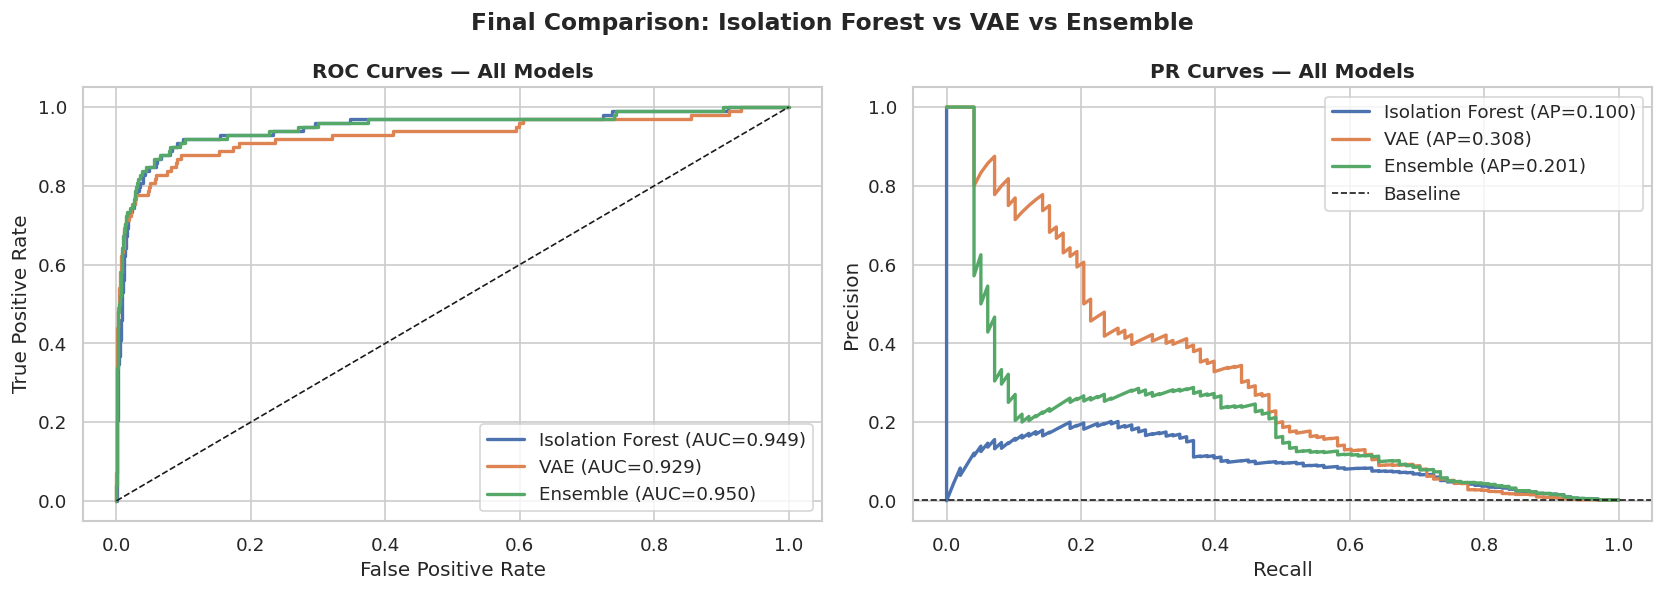


All done! Notebook complete.


In [63]:
# ── Final Summary Plot ────────────────────────────────────────────────────────
all_models = {
    'Isolation Forest': (iso_anomaly_scores, iso_preds),
    'VAE':              (vae_recon_errors,   vae_preds),
    'Ensemble':         (ensemble_scores,    ensemble_preds),
}

colors_map = {
    'Isolation Forest': '#4C72B0',
    'VAE':              '#DD8452',
    'Ensemble':         '#55A868'
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, (scores, preds) in all_models.items():
    fpr_, tpr_, _ = roc_curve(y_test, scores)
    auc_ = roc_auc_score(y_test, scores)
    axes[0].plot(fpr_, tpr_, label=f'{name} (AUC={auc_:.3f})',
                 lw=2, color=colors_map[name])

    prec_, rec_, _ = precision_recall_curve(y_test, scores)
    ap_ = average_precision_score(y_test, scores)
    axes[1].plot(rec_, prec_, label=f'{name} (AP={ap_:.3f})',
                 lw=2, color=colors_map[name])

axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves — All Models', fontsize=12, fontweight='bold')
axes[0].legend()

axes[1].axhline(y=y_test.mean(), color='k', linestyle='--', lw=1, label='Baseline')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('PR Curves — All Models', fontsize=12, fontweight='bold')
axes[1].legend()

plt.suptitle('Final Comparison: Isolation Forest vs VAE vs Ensemble',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nAll done! Notebook complete.')